## Импорты и утилиты

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cvxpy as cp

np.random.seed(42)
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 20)

In [ ]:

data = pd.read_csv('full_data.csv', index_col='openTime')
data.index = pd.to_datetime(data.index)

ret_columns = [c for c in data.columns if '_ret' in c]
close_columns = [c for c in data.columns if '_close' in c]

ret = data[ret_columns].copy()
close = data[close_columns].copy()

ret.columns = [c.replace('_ret','') for c in ret.columns]
close.columns = [c.replace('_close','') for c in close.columns]

print("ret columns sample:", ret.columns[:5])
print("close columns sample:", close.columns[:5])
print("columns equal:", ret.columns.equals(close.columns))

ret columns sample: Index(['AAVEUSDT', 'ADAUSDT', 'ALGOUSDT', 'ATOMUSDT', 'AVAXUSDT'], dtype='object')
close columns sample: Index(['AAVEUSDT', 'ADAUSDT', 'ALGOUSDT', 'ATOMUSDT', 'AVAXUSDT'], dtype='object')
columns equal: True


In [ ]:
lookback = 21
w = (close / close.shift(9) - 1)

w_mean = w.rolling(lookback).mean()
w_std = w.rolling(lookback).std(ddof=0) + 1e-12
w = (w - w_mean) / w_std

w = w.sub(w.mean(axis=1), axis=0)

row_sum = w.abs().sum(axis=1)
w = w.div(row_sum.where(row_sum != 0, np.nan), axis=0)

w = w.fillna(0)

In [ ]:

pnl = (w.shift(1) * ret).sum(axis=1)

def calc_metrics(pnl, w):
    pnl_sum = pnl.sum()
    vol = pnl.std()
    sharpe = (pnl.mean() / vol) * np.sqrt(len(pnl) // 4) if vol != 0 else np.nan
    max_dd = ((pnl.cumsum().cummax() - pnl.cumsum()) / (1 + pnl.cumsum().cummax())).max()
    tvr = (w.diff().abs()).sum(axis=1).resample('1D').sum().mean()
    pm = pnl_sum / tvr if tvr != 0 else np.nan

    return pd.DataFrame({
        'pnl_sum': [pnl_sum],
        'volatility': [vol],
        'sharpe': [sharpe],
        'max_dd': [max_dd],
        'tvr': [tvr],
        'profit_margin': [pm]
    })

res1 = calc_metrics(pnl, w)
res1.index = ['market_neutral']

In [ ]:
# 4. Расчет betas_hat
mkt_s = ret.mean(axis=1)
X = np.column_stack([np.ones(len(mkt_s)), mkt_s.values])

T, N = ret.shape
betas = np.full((T, N), np.nan)

for t in range(6 * 7, T + 1):
    sl = slice(t - 6 * 7, t)
    y_win = ret.iloc[sl].values
    X_win = X[sl]
    coef, *_ = np.linalg.lstsq(X_win, y_win, rcond=None)
    betas[t - 1, :] = coef[1, :]

betas_hat = pd.DataFrame(betas, index=ret.index, columns=ret.columns)

In [ ]:
beta_neut_w = []

N_skip = 5
last_w = None

for i, t in enumerate(betas_hat.index):

    s = w.loc[t].values
    beta = betas_hat.loc[t].values

    if np.any(np.isnan(s)) or np.any(np.isnan(beta)):
        beta_neut_w.append(last_w if last_w is not None else np.zeros_like(s))
        continue

    if i % N_skip != 0 and last_w is not None:
        beta_neut_w.append(last_w)
        continue

    x = cp.Variable(N)

    objective = cp.Minimize(cp.sum_squares(x - s))

    constraints = [
        cp.sum(x) == 0,
        beta @ x == 0
    ]

    prob = cp.Problem(objective, constraints)

    try:
        prob.solve(solver=cp.SCS, verbose=False)
        last_w = x.value
    except:
      pass
    beta_neut_w.append(last_w)
beta_neut_w = pd.DataFrame(beta_neut_w, index=betas_hat.index, columns=w.columns)
beta_neut_w = beta_neut_w.ffill()

# нормализация
row_sum = beta_neut_w.abs().sum(axis=1)
beta_neut_w = beta_neut_w.div(row_sum.replace(0, np.nan), axis=0)
beta_neut_w = beta_neut_w.fillna(0)


In [ ]:
#  Backtest beta-нейтральной стратегии
pnl_beta = (beta_neut_w.shift(1) * ret.loc[beta_neut_w.index]).sum(axis=1)
res2 = calc_metrics(pnl_beta, beta_neut_w)
res2.index = ['beta_neutral']

In [ ]:
strategy_beta = []
for t in beta_neut_w.index:
    beta = betas_hat.loc[t].values
    weights = beta_neut_w.loc[t].values
    strategy_beta.append(np.nansum(beta * weights))

print("Среднее абсолютное значение стратегии beta:", np.nanmean(np.abs(strategy_beta)))



Среднее абсолютное значение стратегии beta: 0.007389789183552943


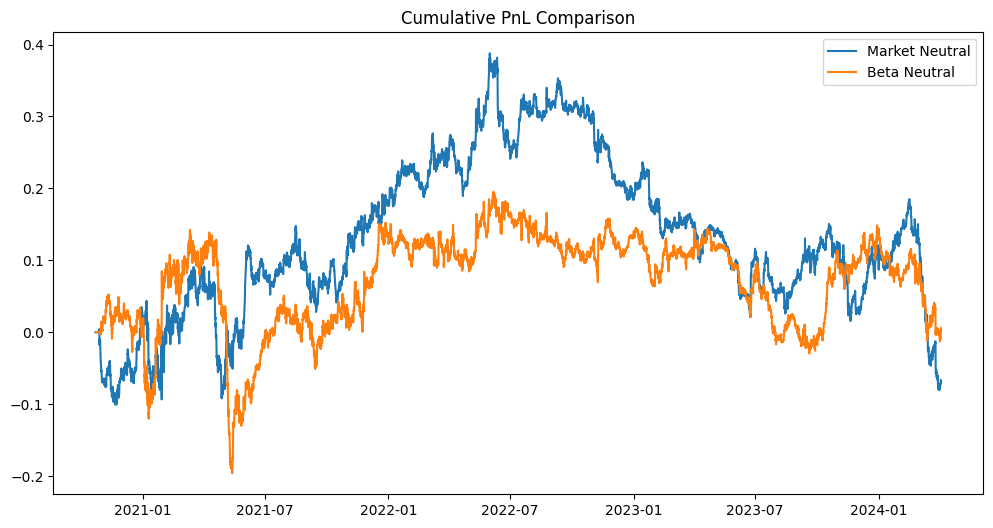

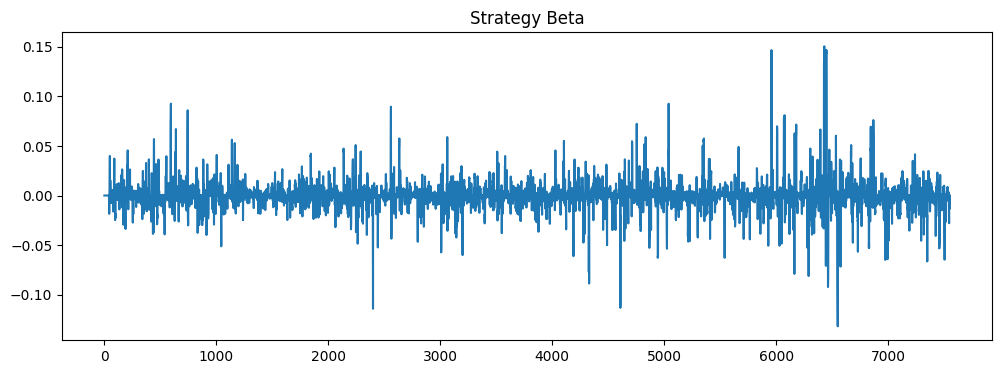

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(pnl.cumsum(), label="Market Neutral")
plt.plot(pnl_beta.cumsum(), label="Beta Neutral")

plt.title("Cumulative PnL Comparison")
plt.legend()
plt.show()

plt.figure(figsize=(12,4))

plt.plot(strategy_beta)

plt.title("Strategy Beta")
plt.show()

In [ ]:

metrics = pd.concat([res1, res2])
print(metrics)

                 pnl_sum  volatility    sharpe    max_dd       tvr  profit_margin
market_neutral -0.069060    0.004253 -0.093410  0.337173  8.148687      -0.008475
beta_neutral    0.004324    0.004036  0.006164  0.296270  1.706907       0.002533
